In [1]:
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import candidate
import uproot
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import json
import hist
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
import pickle, glob
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)


mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-fpkrx9il because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [37]:

# import awkward as ak
# import hist
# from coffea import processor


# class MyProcessor(processor.ProcessorABC):
#     def __init__(self):
#         pass

#     def process(self, events):
#         dataset = events.metadata["dataset"]

#         mass_a = events.mass_A            # shape: (n_events, 2)
#         score = events.classifier_score   # shape: (n_events, 2)

#         # -------------------------------------------------------------
#         # 1. Select events where BOTH mass_A candidates lie in [2.6, 10] GeV
#         # -------------------------------------------------------------
#         in_mass_window = (mass_a >= 2.6) & (mass_a <= 10.0)
#         both_in_window = ak.all(in_mass_window, axis=1)

#         sel_mass = mass_a[both_in_window]
#         sel_score = score[both_in_window]

#         # -------------------------------------------------------------
#         # 2. Split into: both scores < 0.5, vs. both scores >= 0.5
#         # -------------------------------------------------------------
#         both_low_score = ak.all(sel_score < 0.5, axis=1)
#         both_high_score = ak.all(sel_score >= 0.5, axis=1)

#         mass_low = ak.flatten(sel_mass[both_low_score], axis=None)
#         mass_high = ak.flatten(sel_mass[both_high_score], axis=None)

#         # -------------------------------------------------------------
#         # Histograms
#         # -------------------------------------------------------------
#         h_mass_low = hist.Hist(
#             hist.axis.Regular(21, 2.4, 10.4, name="mass", label=r"$m_{A}$ [GeV] (score < 0.5)"),
#             storage=hist.storage.Double(),
#         )
#         h_mass_low.fill(mass=mass_low)

#         h_mass_high = hist.Hist(
#             hist.axis.Regular(21, 2.4, 10.4, name="mass", label=r"$m_{A}$ [GeV] (score >= 0.5)"),
#             storage=hist.storage.Double(),
#         )
#         h_mass_high.fill(mass=mass_high)

#         return {
#             dataset: {
#                 "entries": len(events),
#                 "selected_entries": int(ak.sum(both_in_window)),
#                 "mass_A_low_score": h_mass_low,
#                 "mass_A_high_score": h_mass_high,
#             }
#         }

#     def postprocess(self, accumulator):
#         return accumulator


import awkward as ak
import hist
from coffea import processor


class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events):
        dataset = events.metadata["dataset"]

        mass_a = events.mass_A            # shape: (n_events, 2)
        score = events.classifier_score   # shape: (n_events, 2)

        # -------------------------------------------------------------
        # 0. Guard: require exactly 2 entries per event before doing
        #    any [:, 0] / [:, 1] indexing or ak.all reductions
        # -------------------------------------------------------------
        has_two = (ak.num(mass_a, axis=1) == 2) & (ak.num(score, axis=1) == 2)
        mass_a = mass_a[has_two]
        score = score[has_two]

        # -------------------------------------------------------------
        # 1. Select events where BOTH mass_A candidates lie in [2.6, 10] GeV
        # -------------------------------------------------------------
        in_mass_window = (mass_a >= 2.6) & (mass_a <= 10.0)
        both_in_window = ak.all(in_mass_window, axis=1)

        sel_mass = mass_a[both_in_window]
        sel_score = score[both_in_window]

        # Per-event mass difference between the two mass_A candidates
        mass_diff = abs(sel_mass[:, 0] - sel_mass[:, 1])

        # -------------------------------------------------------------
        # 2. Score regions + mass-difference cut
        #    high score: both >= 0.5  AND  mass_diff <= 2
        #    low score:  both <  0.5  AND  mass_diff >  2
        # -------------------------------------------------------------
        both_high_score = ak.all(sel_score >= 0.5, axis=1)
        both_low_score = ak.all(sel_score < 0.5, axis=1)

        high_sel = both_high_score & (mass_diff <= 2.0)
        low_sel = both_low_score & (mass_diff > 2.0)

        mass_low = ak.flatten(sel_mass[low_sel], axis=None)
        mass_high = ak.flatten(sel_mass[high_sel], axis=None)

        # -------------------------------------------------------------
        # Histograms
        # -------------------------------------------------------------
        h_mass_low = hist.Hist(
            hist.axis.Regular(21, 2.4, 10.4, name="mass", label=r"$m_{A}$ [GeV] (score < 0.5, $\Delta m$ > 2)"),
            storage=hist.storage.Double(),
        )
        h_mass_low.fill(mass=mass_low)

        h_mass_high = hist.Hist(
            hist.axis.Regular(21, 2.4, 10.4, name="mass", label=r"$m_{A}$ [GeV] (score >= 0.5, $\Delta m$ <= 2)"),
            storage=hist.storage.Double(),
        )
        h_mass_high.fill(mass=mass_high)

        return {
            dataset: {
                "entries": len(events),
                "selected_entries": int(ak.sum(both_in_window)),
                "mass_A_low_score": h_mass_low,
                "mass_A_high_score": h_mass_high,
            }
        }

    def postprocess(self, accumulator):
        return accumulator

In [38]:
with open("Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)


with open("Background_Wjets_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_Wjets_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_TTBar_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_TTBar_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)
with open("Background_QCD_with_mass_classifier_infernce_miniAOD_June15.json", "r") as fin:
    Background_QCD_with_mass_classifier_infernce_miniAOD_June15 = json.load(fin)


with open("list_Ntuples_data_miniAOD_Aug_5_2026_inference_root_to_root.json", "r") as fin:
    data_miniAOD_Aug_5_2026_inference_root_to_root = json.load(fin)


fileset = {
    'Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15
    ,'Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15': Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15


    
    ,'Background_QCD_with_mass_classifier_infernce_miniAOD_June15': Background_QCD_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_Wjets_with_mass_classifier_infernce_miniAOD_June15': Background_Wjets_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15': Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_TTBar_with_mass_classifier_infernce_miniAOD_June15': Background_TTBar_with_mass_classifier_infernce_miniAOD_June15
    ,'Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15': Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15

    
    ,'data_miniAOD_Aug_5_2026_inference_root_to_root':data_miniAOD_Aug_5_2026_inference_root_to_root



}




In [53]:
futures_run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=4),
    schema=BaseSchema,
    skipbadfiles=True,   # don't crash the whole run on one bad file
    xrootdtimeout=120,
    # maxchunks=2,
)

out = futures_run(
    fileset,
    treename='/fevt/RHTree',
    # "RHTree",
    processor_instance=MyProcessor()
)
with open('inference_data_signal_background_mass_clssifier_score_2p4_10p4_Ge_A1_A2_mass_cut.pkl', 'wb') as f:
    pickle.dump(out, f)

out

Output()

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1107: UserWarning: Failed to open file: WorkItem(dataset='data_miniAOD_Aug_5_2026_inference_root_to_root', filename='root://cmseos.fnal.gov//store/group/lpcml/bbbam/Ntuples_data_miniAOD_Aug_5_2026_inference_root_to_root/output_2326_added_mass_classifier_inference.root', treename='/fevt/RHTree', entrystart=0, entrystop=458, fileuuid=b'\xe6\xbcN0\x9aU\x11\xf1\xab\x92\x96\xbe\xe1\x83\xbe\xef', usermeta={}). The error was: OSError('Failed to open file: [ERROR] Server responded with an error: [3014] Unable to open file  /store/group/lpcml/bbbam/Ntuples_data_miniAOD_Aug_5_2026_inference_root_to_root/output_2326_added_mass_classifier_inference.root; Network is unreachable\n').
  warnings.warn(str(e))
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1107: UserWarning: Failed to open file: WorkItem(dataset='data_miniAOD_Aug_5_2026_inference_root_to_root', filename='root://cmseos.fnal.gov//store/group/lpcml/

{'data_miniAOD_Aug_5_2026_inference_root_to_root': {'entries': 210612,
  'selected_entries': 56316,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score < 0.5, $\\Delta m$ > 2)'), storage=Double()) # Sum: 22892.0,
  'mass_A_high_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score >= 0.5, $\\Delta m$ <= 2)'), storage=Double()) # Sum: 8592.0},
 'Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15': {'entries': 31147,
  'selected_entries': 5939,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score < 0.5, $\\Delta m$ > 2)'), storage=Double()) # Sum: 4632.0,
  'mass_A_high_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score >= 0.5, $\\Delta m$ <= 2)'), storage=Double()) # Sum: 114.0},
 'Background_TTBar_with_mass_classifier_infernce_miniAOD_June15': {'entries': 73307,
  'selected_entries': 19126,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mas

In [2]:
with open('inference_data_signal_background_mass_clssifier_score_2p4_10p4_GeV.pkl', 'rb') as f:
    out = pickle.load(f)
out

{'data_miniAOD_Aug_5_2026_inference_root_to_root': {'entries': 211970,
  'selected_entries': 90771,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score < 0.5)'), storage=Double()) # Sum: 71179.0,
  'mass_A_high_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score >= 0.5)'), storage=Double()) # Sum: 27861.0},
 'Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15': {'entries': 31204,
  'selected_entries': 10186,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score < 0.5)'), storage=Double()) # Sum: 13180.0,
  'mass_A_high_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score >= 0.5)'), storage=Double()) # Sum: 721.0},
 'Background_TTBar_with_mass_classifier_infernce_miniAOD_June15': {'entries': 73307,
  'selected_entries': 34180,
  'mass_A_low_score': Hist(Regular(21, 2.4, 10.4, name='mass', label='$m_{A}$ [GeV] (score < 0.5)'), storage=Double()) # Sum: 

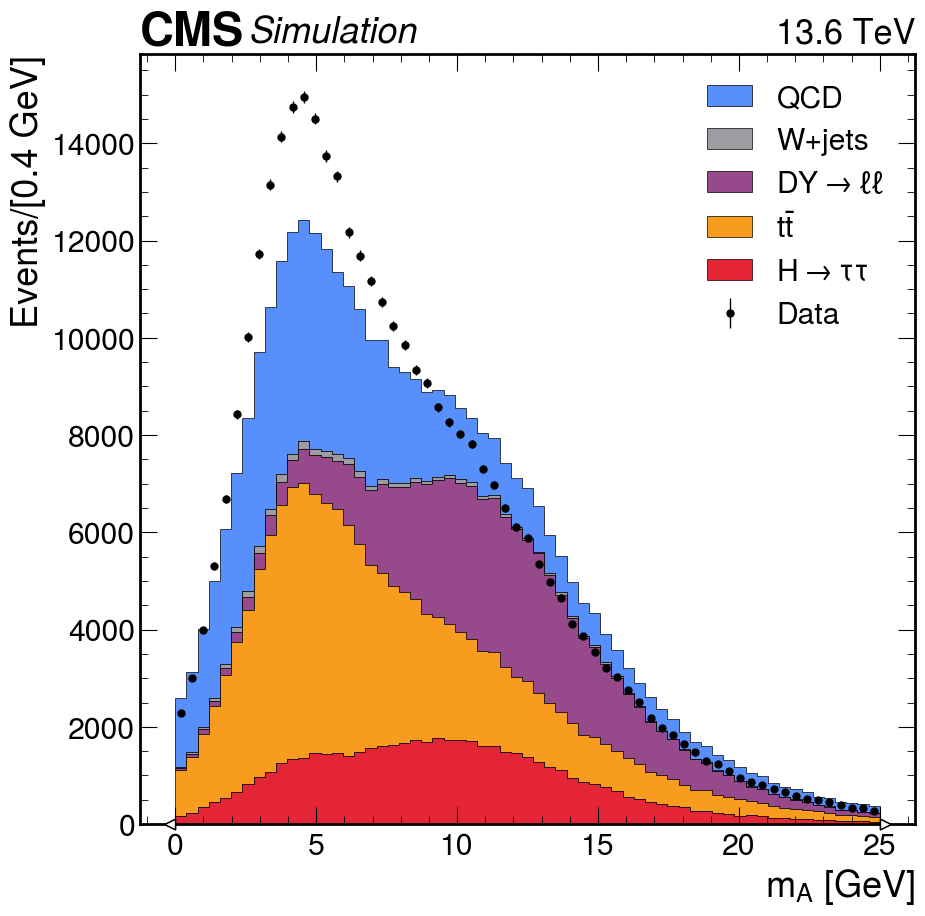

In [4]:
# Create a single output directory for saving plots
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check_data_MC"
os.makedirs(outdir, exist_ok=True)


PKL_PATH = "inference_data_signal_background_mass_clssifier_score.pkl"  # <-- point this at your coffea output pickle
NORM_FACTOR = 1.0
VARIABLE = "mass_A"

DATA_KEY = "data_miniAOD_Aug_5_2026_inference_root_to_root"

# dataset key -> (legend label, fill color)
BACKGROUNDS = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": (r"$H\to\tau\tau$", "#e42536"),
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": (r"$t\bar{t}$", "#f89c20"),
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": (r"$DY\to \ell\ell$", "#964a8b"),
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": ("W+jets", "#9c9ca1"),
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": ("QCD", "#5790fc"),
}

# Stacking order (bottom -> top)
STACK_ORDER = [
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15",
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15",
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15",
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15",
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15",
]



with open(PKL_PATH, "rb") as f:
    output = pickle.load(f)

bkg_hists, labels, colors = [], [], []
for key in STACK_ORDER:
    bkg_hists.append(output[key][VARIABLE] * NORM_FACTOR)
    label, color = BACKGROUNDS[key]
    labels.append(label)
    colors.append(color)




data_hist = output[DATA_KEY][VARIABLE]

fig, ax = plt.subplots(dpi=100)

hep.histplot(
    bkg_hists, stack=True, histtype="fill", rasterized=True,
    label=labels, color=colors, edgecolor="black", linewidth=0.5,
    ax=ax,
)


hep.histplot(
    data_hist, histtype="errorbar", color="black",
    label="Data", ax=ax,rasterized=True,
    yerr=np.sqrt(data_hist.values()),   # Poisson error bars
)

ax.set_ylabel("Events/[0.4 GeV]")
ax.legend()
hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)
# fig.savefig(f"{outdir}/mass_A_bkg_data_stack_no_cut.pdf", dpi=300, bbox_inches="tight")
plt.show()

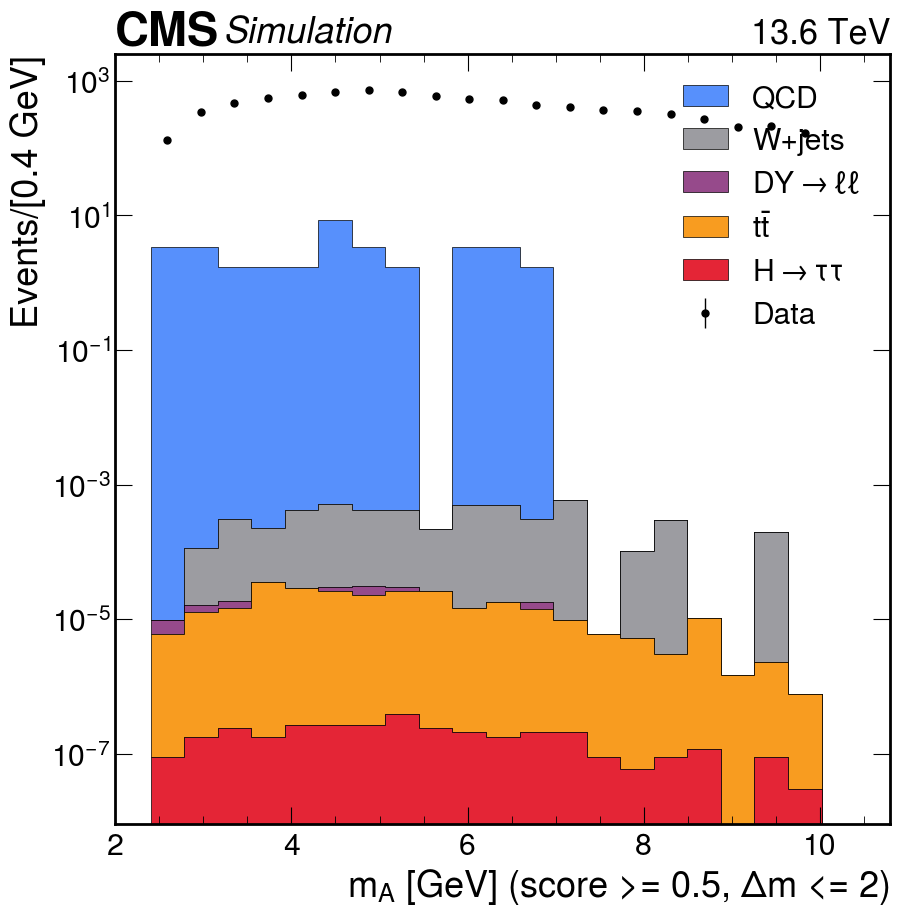

In [15]:
# Create a single output directory for saving plots
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check_data_MC"
os.makedirs(outdir, exist_ok=True)


PKL_PATH = "inference_data_signal_background_mass_clssifier_score_2p4_10p4_Ge_A1_A2_mass_cut.pkl"  # <-- point this at your coffea output pickle
NORM_FACTOR = 1.0
VARIABLE = "mass_A_high_score"

DATA_KEY = "data_miniAOD_Aug_5_2026_inference_root_to_root"

# dataset key -> (legend label, fill color)
BACKGROUNDS = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": (r"$H\to\tau\tau$", "#e42536"),
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": (r"$t\bar{t}$", "#f89c20"),
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": (r"$DY\to \ell\ell$", "#964a8b"),
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": ("W+jets", "#9c9ca1"),
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": ("QCD", "#5790fc"),
}

# Stacking order (bottom -> top)
STACK_ORDER = [
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15",
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15",
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15",
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15",
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15",
]


#----------------------------------------------------------------------
# MC normalization: w = sigma * L / Ngen
# Cross sections (pb) and Ngen taken from the MC production table
# ----------------------------------------------------------------------
XSEC = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 3.166e1,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 7.623e2,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 5.453e3,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 6.808e4,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1.448e9,
}

NGEN = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 1_488_000,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 1_461_000,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 1_984_000,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 987_000,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1_192_000,
}

LUMI = 0.0014  # pb^-1

WEIGHTS = {key: XSEC[key] * LUMI / NGEN[key] for key in XSEC}
with open(PKL_PATH, "rb") as f:
    output = pickle.load(f)

bkg_hists, labels, colors = [], [], []
for key in STACK_ORDER:
    w = WEIGHTS[key]
    bkg_hists.append(output[key][VARIABLE] * w)
    label, color = BACKGROUNDS[key]
    labels.append(label)
    colors.append(color)




data_hist = output[DATA_KEY][VARIABLE]

fig, ax = plt.subplots(dpi=100)

hep.histplot(
    bkg_hists, stack=True, histtype="fill", rasterized=True,
    label=labels, color=colors, edgecolor="black", linewidth=0.5,
    ax=ax,
)


hep.histplot(
    data_hist, histtype="errorbar", color="black",
    label="Data", ax=ax,rasterized=True,
    yerr=np.sqrt(data_hist.values()),   # Poisson error bars
)

ax.set_ylabel("Events/[0.4 GeV]")
ax.legend()
hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

ax.set_yscale("log")
# fig.savefig(f"{outdir}/mass_A_backgound_estimation_24p_10p4_GeV_high_classifier_score_A1_A2_mass_cut_normalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

1192000


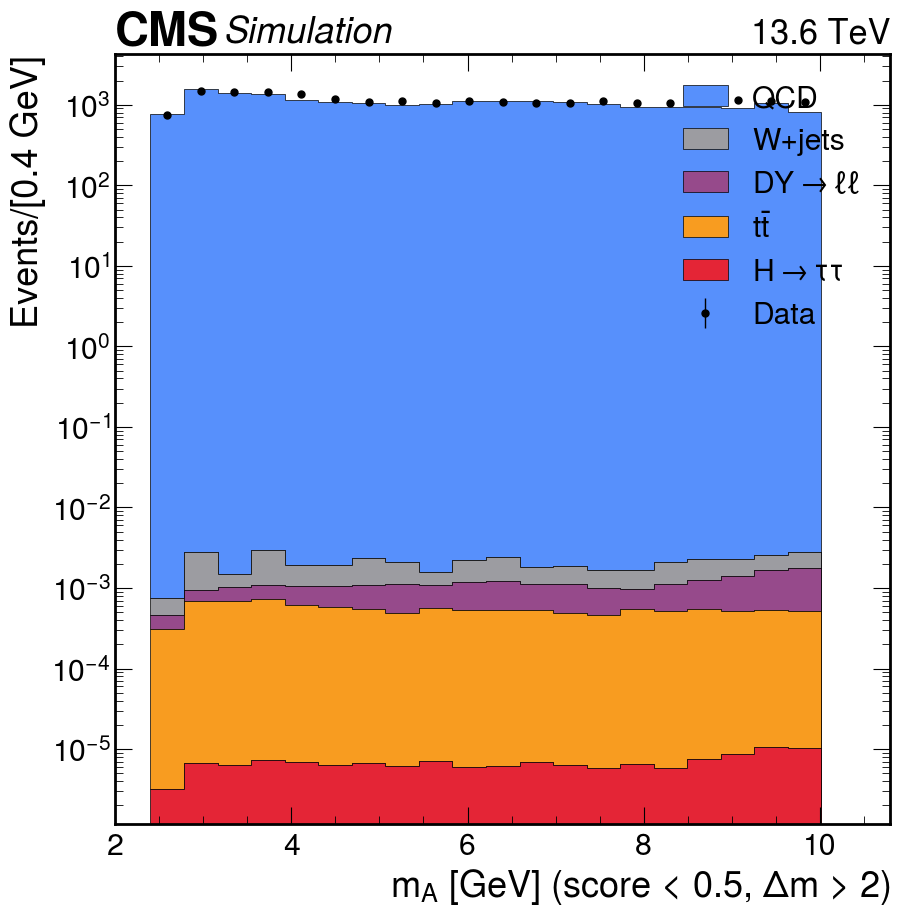

In [48]:
# Create a single output directory for saving plots
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check_data_MC"
os.makedirs(outdir, exist_ok=True)


PKL_PATH = "inference_data_signal_background_mass_clssifier_score_2p4_10p4_Ge_A1_A2_mass_cut.pkl"  # <-- point this at your coffea output pickle
# NORM_FACTOR = 1.0
VARIABLE = "mass_A_low_score"

DATA_KEY = "data_miniAOD_Aug_5_2026_inference_root_to_root"

# dataset key -> (legend label, fill color)
BACKGROUNDS = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": (r"$H\to\tau\tau$", "#e42536"),
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": (r"$t\bar{t}$", "#f89c20"),
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": (r"$DY\to \ell\ell$", "#964a8b"),
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": ("W+jets", "#9c9ca1"),
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": ("QCD", "#5790fc"),
}

# Stacking order (bottom -> top)
STACK_ORDER = [
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15",
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15",
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15",
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15",
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15",
]

#----------------------------------------------------------------------
# MC normalization: w = sigma * L / Ngen
# Cross sections (pb) and Ngen taken from the MC production table
# ----------------------------------------------------------------------
XSEC = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 3.166e1,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 7.623e2,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 5.453e3,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 6.808e4,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1.448e9,
}

NGEN = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 1_488_000,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 1_461_000,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 1_984_000,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 987_000,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1_192_000,
}

LUMI = 0.0014  # pb^-1

WEIGHTS = {key: XSEC[key] * LUMI / NGEN[key] for key in XSEC}


with open(PKL_PATH, "rb") as f:
    output = pickle.load(f)

bkg_hists, labels, colors = [], [], []
for key in STACK_ORDER:
    w = WEIGHTS[key]
    bkg_hists.append(output[key][VARIABLE] * w)
    label, color = BACKGROUNDS[key]
    labels.append(label)
    colors.append(color)




data_hist = output[DATA_KEY][VARIABLE]

fig, ax = plt.subplots(dpi=100)

hep.histplot(
    bkg_hists, stack=True, histtype="fill", rasterized=True,
    label=labels, color=colors, edgecolor="black", linewidth=0.5,
    ax=ax,
)


hep.histplot(
    data_hist, histtype="errorbar", color="black",
    label="Data", ax=ax,rasterized=True,
    yerr=np.sqrt(data_hist.values()),   # Poisson error bars
)

ax.set_ylabel("Events/[0.4 GeV]")
ax.legend()
hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

ax.set_yscale("log")
# fig.savefig(f"{outdir}/mass_A_backgound_estimation_24p_10p4_GeV_low_classifier_score_A1_A2_mass_cut_normalized.pdf", dpi=300, bbox_inches="tight")

plt.show()

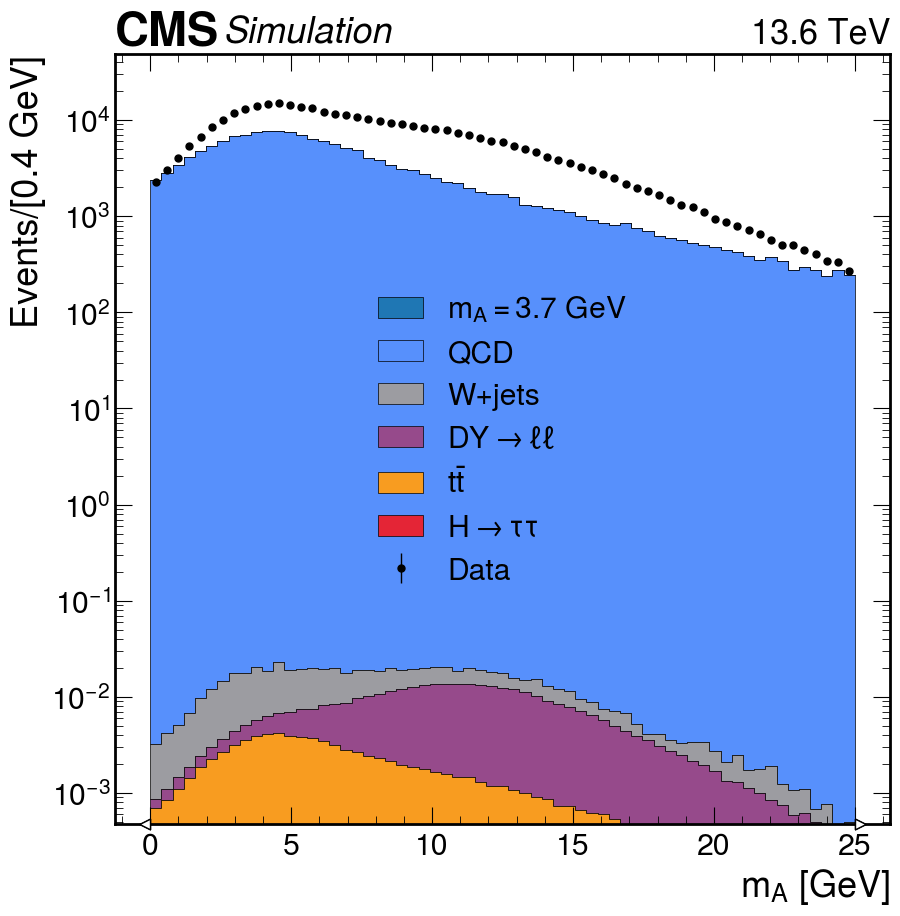

In [26]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

# ----------------------------------------------------------------------
# Output directory
# ----------------------------------------------------------------------
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check_data_MC"
os.makedirs(outdir, exist_ok=True)

PKL_PATH = "inference_data_signal_background_mass_clssifier_score.pkl"  # <-- point this at your coffea output pickle
VARIABLE = "mass_A"

DATA_KEY = "data_miniAOD_Aug_5_2026_inference_root_to_root"

# dataset key -> (legend label, fill color)
BACKGROUNDS = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": (r"$H\to\tau\tau$", "#e42536"),
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": (r"$t\bar{t}$", "#f89c20"),
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": (r"$DY\to \ell\ell$", "#964a8b"),
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": ("W+jets", "#9c9ca1"),
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": ("QCD", "#5790fc"),
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": (r"$m_A=3.7$ GeV", "#1f77b4"),
}

# Stacking order (bottom -> top)
STACK_ORDER = [
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15",
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15",
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15",
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15",
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15",
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15"
]

# ----------------------------------------------------------------------
# MC normalization: w = sigma * L / Ngen
# Cross sections (pb) and Ngen taken from the MC production table
# ----------------------------------------------------------------------
XSEC = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 3.166e1,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 7.623e2,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 5.453e3,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 6.808e4,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1.448e9,
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": 4.887e-2,
}

NGEN = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 1_488_000,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 1_461_000,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 1_984_000,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 987_000,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1_192_000,
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": 290_700,
}

LUMI = 0.0014  # pb^-1

WEIGHTS = {key: XSEC[key] * LUMI / NGEN[key] for key in XSEC}

# ----------------------------------------------------------------------
# Load histograms
# ----------------------------------------------------------------------
with open(PKL_PATH, "rb") as f:
    output = pickle.load(f)

bkg_hists, labels, colors = [], [], []
for key in STACK_ORDER:
    w = WEIGHTS[key]
    bkg_hists.append(output[key][VARIABLE] * w)
    label, color = BACKGROUNDS[key]
    labels.append(label)
    colors.append(color)

data_hist = output[DATA_KEY][VARIABLE]

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------
fig, ax = plt.subplots(dpi=100)

hep.histplot(
    bkg_hists, stack=True, histtype="fill", rasterized=True,
    label=labels, color=colors, edgecolor="black", linewidth=0.5,
    ax=ax,
)

hep.histplot(
    data_hist, histtype="errorbar", color="black",
    label="Data", ax=ax, rasterized=True,
    yerr=np.sqrt(data_hist.values()),  # Poisson error bars
)

ax.set_ylabel("Events/[0.4 GeV]")
ax.legend()
hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

ax.set_yscale("log")
# fig.savefig(f"{outdir}/mass_A_bkg_data_stack_no_cut.pdf", dpi=300, bbox_inches="tight")
plt.show()

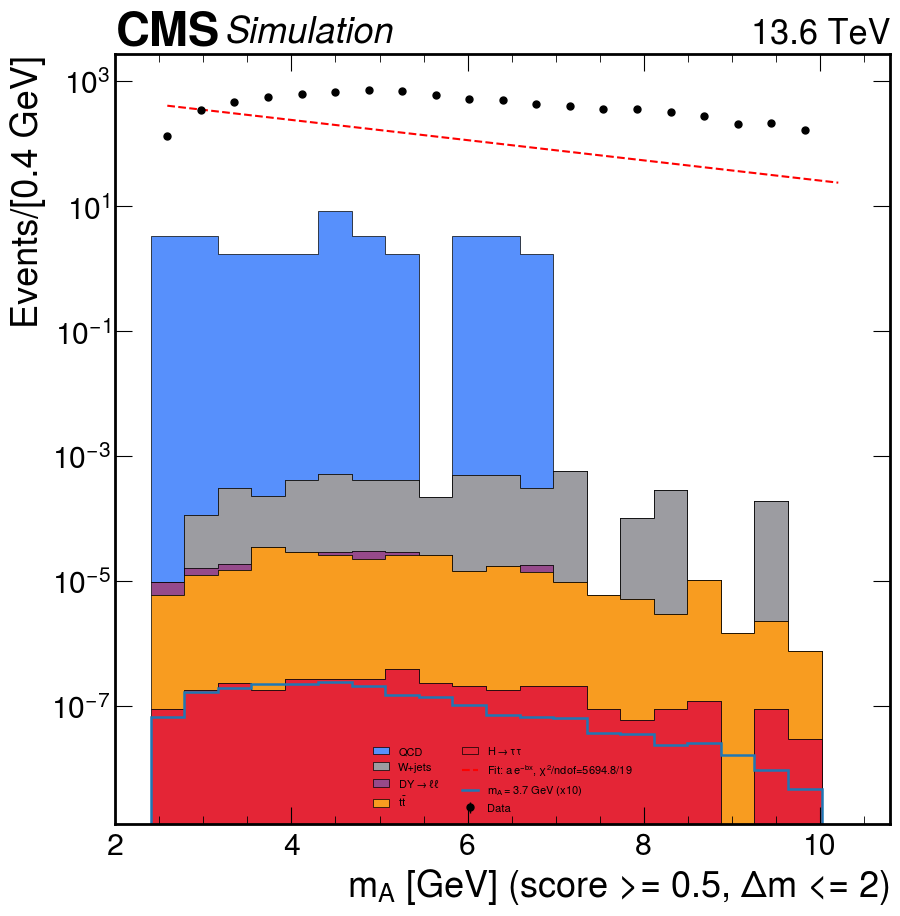

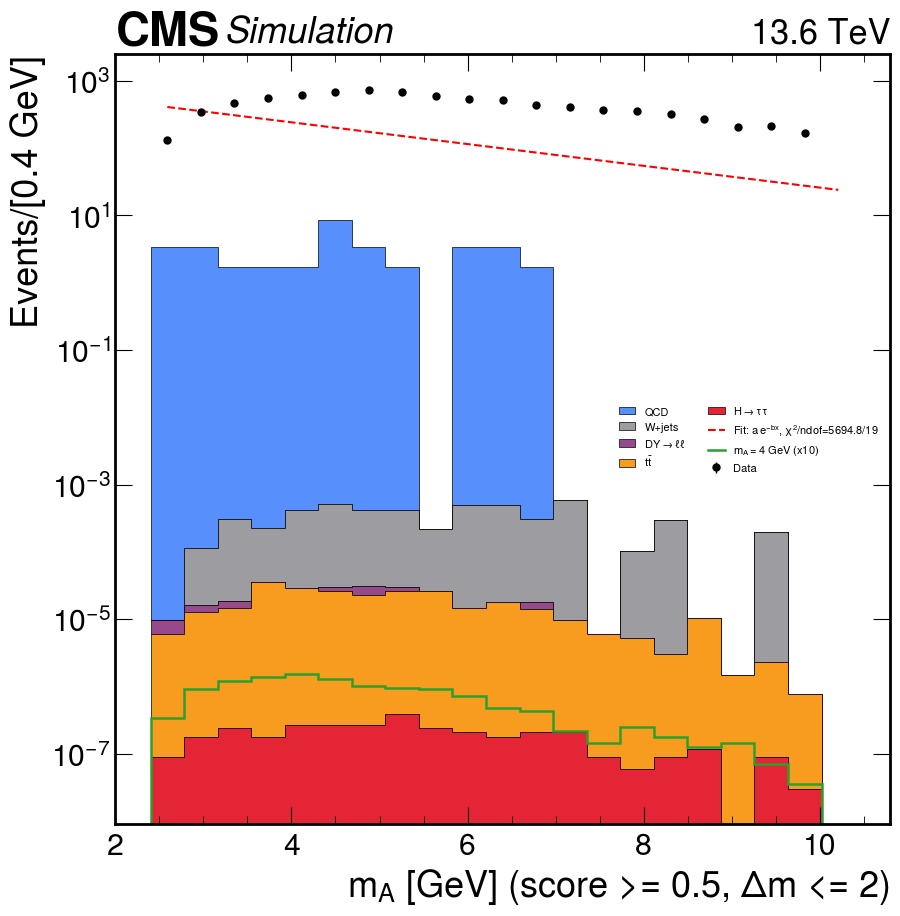

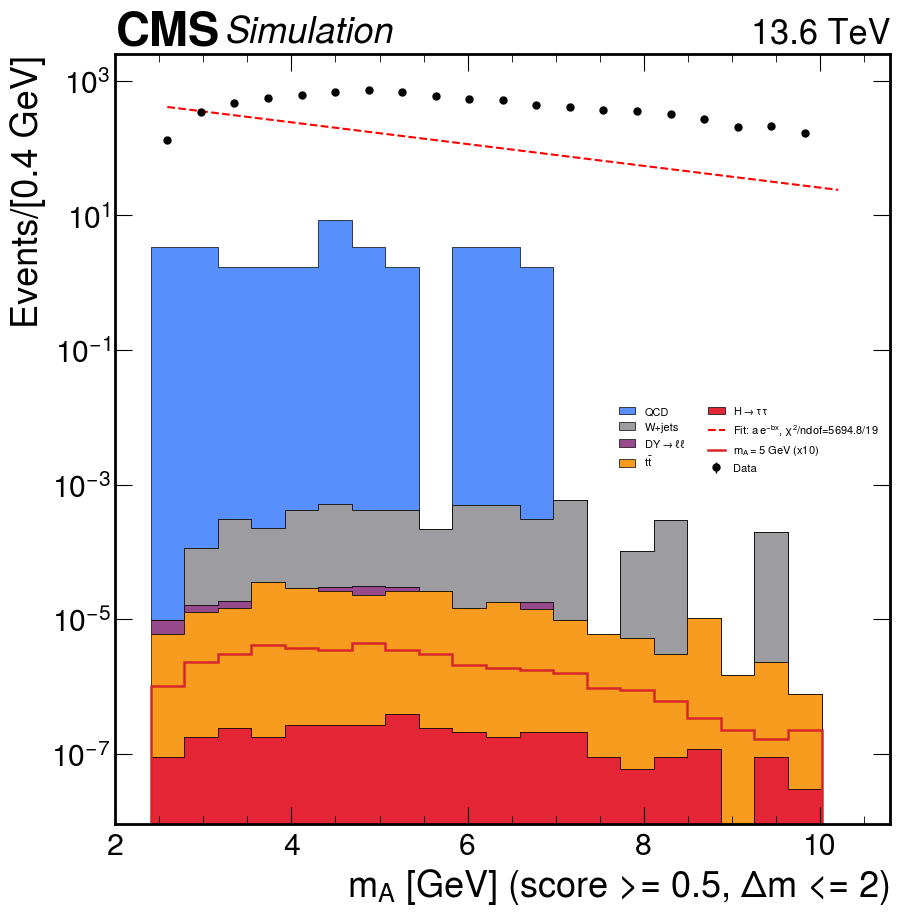

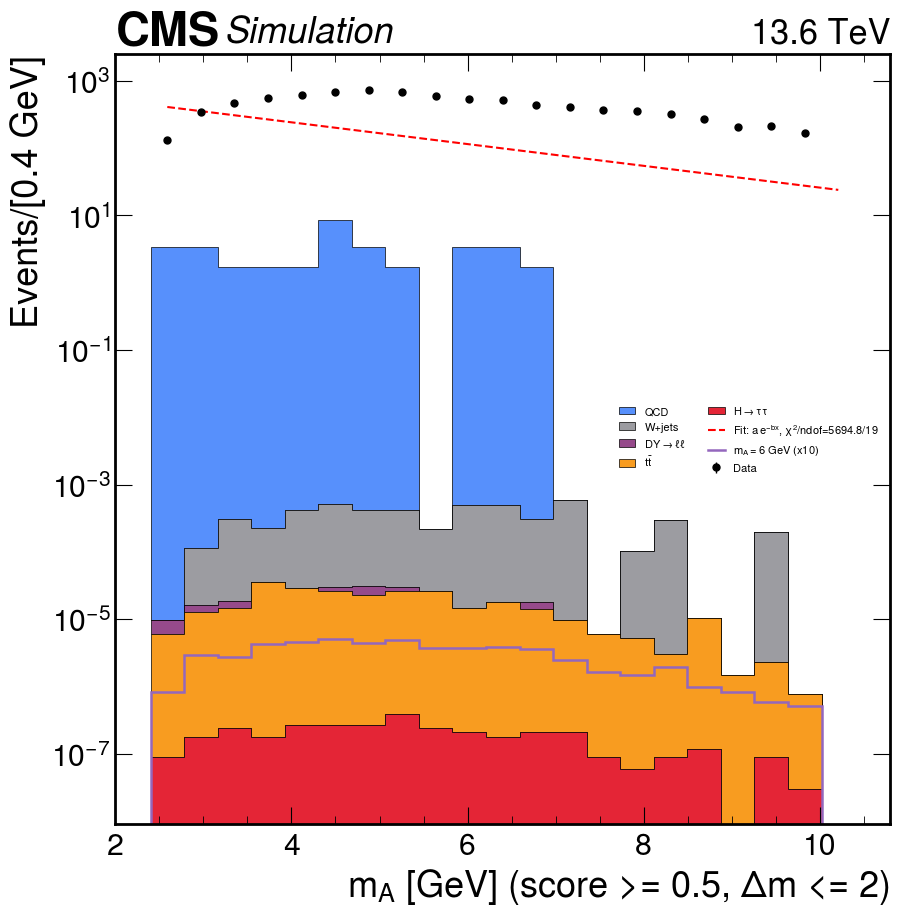

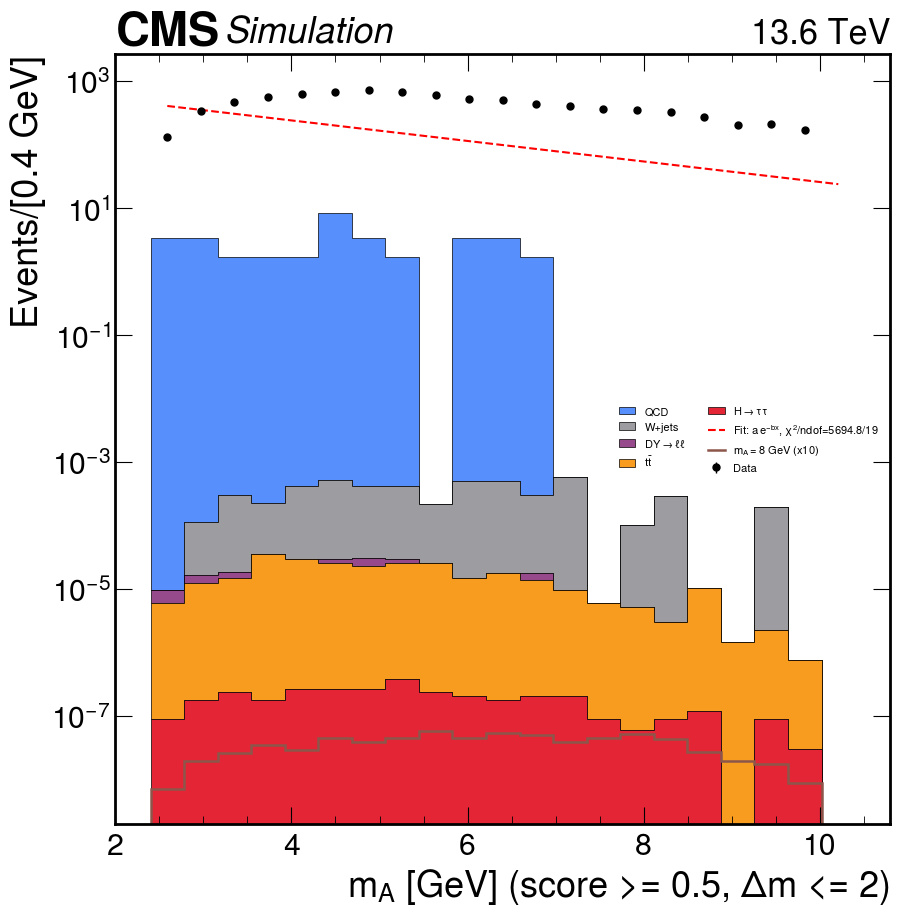

In [10]:
from scipy.optimize import curve_fit

# Create a single output directory for saving plots
outdir = "../analysis_run3/AN_Note_Plot/plots_mass_classifier_inference_check_data_MC"
os.makedirs(outdir, exist_ok=True)


PKL_PATH = "inference_data_signal_background_mass_clssifier_score_2p4_10p4_Ge_A1_A2_mass_cut.pkl"  # <-- point this at your coffea output pickle
# NORM_FACTOR = 1.0
# Region to plot: low-score sideband/CR (score < 0.5)
VARIABLE = "mass_A_high_score"

# dataset key -> (legend label, fill color)
BACKGROUNDS = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": (r"$H\to\tau\tau$", "#e42536"),
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": (r"$t\bar{t}$", "#f89c20"),
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": (r"$DY\to \ell\ell$", "#964a8b"),
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": ("W+jets", "#9c9ca1"),
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": ("QCD", "#5790fc"),
}

# Stacking order (bottom -> top)
STACK_ORDER = [
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15",
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15",
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15",
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15",
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15",
]

# dataset key -> (legend label, line color)
SIGNALS = {
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": (r"$m_A=3.7$ GeV", "#1f77b4"),
    "Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15":   (r"$m_A=4$ GeV",   "#2ca02c"),
    "Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15":   (r"$m_A=5$ GeV",   "#d62728"),
    "Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15":   (r"$m_A=6$ GeV",   "#9467bd"),
    "Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15":   (r"$m_A=8$ GeV",   "#8c564b"),
}

SIGNAL_ORDER = [
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15",
    "Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15",
    "Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15",
    "Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15",
    "Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15",
]

# ----------------------------------------------------------------------
# MC normalization: w = sigma * L / Ngen
# ----------------------------------------------------------------------
XSEC_BKG = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 3.166e1,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 7.623e2,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 5.453e3,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 6.808e4,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1.448e9,
}

NGEN_BKG = {
    "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15": 1_488_000,
    "Background_TTBar_with_mass_classifier_infernce_miniAOD_June15": 1_461_000,
    "Background_DYto2L_with_mass_classifier_infernce_miniAOD_June15": 1_984_000,
    "Background_Wjets_with_mass_classifier_infernce_miniAOD_June15": 987_000,
    "Background_QCD_with_mass_classifier_infernce_miniAOD_June15": 1_192_000,
}

XSEC_SIG = {
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": 4.887e-2,
    "Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15": 3.830e-1,
    "Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15": 1.240e0,
    "Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15": 1.658e0,
    "Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15": 1.959e-2,
}

NGEN_SIG = {
    "Signal_M3p7_GeV_with_mass_classifier_infernce_miniAOD_June15": 290_700,
    "Signal_M4_GeV_with_mass_classifier_infernce_miniAOD_June15": 300_900,
    "Signal_M5_GeV_with_mass_classifier_infernce_miniAOD_June15": 311_100,
    "Signal_M6_GeV_with_mass_classifier_infernce_miniAOD_June15": 313_100,
    "Signal_M8_GeV_with_mass_classifier_infernce_miniAOD_June15": 311_100,
}

LUMI = 0.0014         # pb^-1
SIGNAL_SCALE = 10    # scale signal up for visibility on the plot

WEIGHTS_BKG = {key: XSEC_BKG[key] * LUMI / NGEN_BKG[key] for key in XSEC_BKG}
WEIGHTS_SIG = {key: XSEC_SIG[key] * LUMI / NGEN_SIG[key] for key in XSEC_SIG}

# ----------------------------------------------------------------------
# Load histograms
# ----------------------------------------------------------------------
with open(PKL_PATH, "rb") as f:
    output = pickle.load(f)


# ----------------------------------------------------------------------
# Fit function: smooth exponential fit to the data shape.
# NOTE: this is a "guide the eye" smooth fit, not a signal+background
# extraction fit. Swap this out if you want a different shape
# (e.g. polynomial) or a proper S+B fit at each mass point.
# ----------------------------------------------------------------------
def exp_bkg(x, a, b):
    return a * np.exp(-b * x)


def fit_data(data_hist):
    centers = data_hist.axes[0].centers
    values = data_hist.values()
    errors = np.sqrt(values)
    errors[errors == 0] = 1.0  # avoid zero-weight bins in the fit

    p0 = [max(values.max(), 1.0), 0.3]
    popt, pcov = curve_fit(exp_bkg, centers, values, sigma=errors, p0=p0, maxfev=10000)

    chi2 = np.sum(((values - exp_bkg(centers, *popt)) / errors) ** 2)
    ndof = len(centers) - len(popt)

    x_smooth = np.linspace(centers[0], centers[-1], 200)
    y_smooth = exp_bkg(x_smooth, *popt)

    return x_smooth, y_smooth, popt, chi2, ndof


# ----------------------------------------------------------------------
# Plot: one figure per signal mass point
# ----------------------------------------------------------------------
def make_plot(signal_key, outname):
    bkg_hists, labels, colors = [], [], []
    for key in STACK_ORDER:
        w = WEIGHTS_BKG[key]
        bkg_hists.append(output[key][VARIABLE] * w)
        label, color = BACKGROUNDS[key]
        labels.append(label)
        colors.append(color)

    data_hist = output[DATA_KEY][VARIABLE]

    fig, ax = plt.subplots(dpi=100)

    hep.histplot(
        bkg_hists, stack=True, histtype="fill", rasterized=True,
        label=labels, color=colors, edgecolor="black", linewidth=0.5,
        ax=ax,
    )

    hep.histplot(
        data_hist, histtype="errorbar", color="black",
        label="Data", ax=ax, rasterized=True,
        yerr=np.sqrt(data_hist.values()),   # Poisson error bars
    )

    # Smooth fit to data
    x_smooth, y_smooth, popt, chi2, ndof = fit_data(data_hist)
    ax.plot(
        x_smooth, y_smooth, color="red", linestyle="--", linewidth=1.5,
        label=rf"Fit: $a\,e^{{-bx}}$, $\chi^2$/ndof={chi2:.1f}/{ndof}",
    )

    # Signal overlay (this mass point only), unstacked and scaled for visibility
    w_sig = WEIGHTS_SIG[signal_key]
    sig_label, sig_color = SIGNALS[signal_key]
    sig_hist = output[signal_key][VARIABLE] * w_sig * SIGNAL_SCALE
    hep.histplot(
        sig_hist, histtype="step", linewidth=1.8, color=sig_color,
        label=f"{sig_label} (x{SIGNAL_SCALE})", ax=ax, rasterized=True,
    )

    ax.set_ylabel("Events/[0.4 GeV]")
    ax.set_yscale("log")
    ax.legend(fontsize=8, ncol=2)
    hep.cms.label(
        llabel="Simulation",
        rlabel="13.6 TeV",
        loc=0,
        ax=ax
    )

    # fig.savefig(f"{outdir}/{outname}.pdf", dpi=300, bbox_inches="tight")
    plt.show()


for key in SIGNAL_ORDER:
    outname = f"mass_A_bkg_data_fit_{key}_low_score"
    make_plot(key, outname)

In [5]:
key = "Background_HTo2Tau_with_mass_classifier_infernce_miniAOD_June15"
print(output[key].keys())

dict_keys(['entries', 'Classifier_score', 'mass_A_raw', 'mass_A', 'jetpT'])
